In [ ]:
from IPython.display import display
from numpy.typing import NDArray
from step4_perceptron import TrainLogAnimation
from step6_kernel_svm import History, LogItem, RandomFourierFeatures
from step7_one_class_svm import (
    LinearOneClassSupportVectorMachine,
    init_single_class_dataset,
)


class KernelOneClassSupportVectorMachine(LinearOneClassSupportVectorMachine):
    def __init__(
        self,
        ndim: int = 2,
        gamma: float = 0.5,
        D: int = 3000,
        eta: float = 0.0003,
        nu: float = 0.05,
        tolerance: float = 0.1,
        patience: int = 30,
    ):
        super().__init__(ndim=D * 2, eta=eta)
        self.nu = nu
        self.rff = RandomFourierFeatures(input_features=ndim, gamma=gamma, D=D)
        self.D = D
        self.tolerance = tolerance
        self.patience = patience
        self._convergence_count = 0

    def train(self, Dx: NDArray, Dy: NDArray, epochs: int = 100) -> History:
        history = History(Dx, Dy, epochs)
        history.append(LogItem(self.copy()))

        Dz = self.rff.transform(Dx)

        for i in range(epochs):
            w_old = self.w[:]
            b_old = self.b
            for x_i, y_i, z_i in zip(Dx, Dy, Dz):
                history.append(LogItem(self.copy(), x_i, y_i))
                self.w, self.b = self._train_step(z_i, y_i)

            delta = self._calculate_delta(w_old, b_old)
            print(f"epoch {i + 1}: {delta = }")
            if self._is_converged(delta):
                break
        return history

    def score(self, X: NDArray) -> NDArray:
        if X.shape[-1] != 2 * self.D:
            X = self.rff.transform(X)
        return super().score(X)

epoch 1: delta = np.float64(6.7253354670759)
epoch 2: delta = np.float64(6.124999419865835)
epoch 3: delta = np.float64(5.617838509125298)
epoch 4: delta = np.float64(5.150026098312599)
epoch 5: delta = np.float64(4.723562830943286)
epoch 6: delta = np.float64(4.3348198854010125)
epoch 7: delta = np.float64(3.968904399183944)
epoch 8: delta = np.float64(3.6344873407203826)
epoch 9: delta = np.float64(3.3347042664801556)
epoch 10: delta = np.float64(3.055396374989081)
epoch 11: delta = np.float64(2.794285614691547)
epoch 12: delta = np.float64(2.560981098098642)
epoch 13: delta = np.float64(2.341931533389528)
epoch 14: delta = np.float64(2.1412276690992673)
epoch 15: delta = np.float64(1.9631061610032423)
epoch 16: delta = np.float64(1.7945116252223556)
epoch 17: delta = np.float64(1.628163395307549)
epoch 18: delta = np.float64(1.4920420744978522)
epoch 19: delta = np.float64(1.3619067021453548)
epoch 20: delta = np.float64(1.2424420184259373)
epoch 21: delta = np.float64(1.13271882500

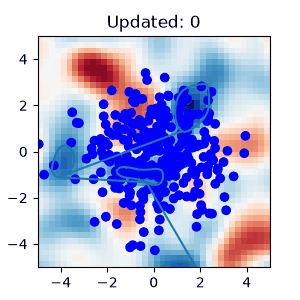

In [ ]:
def main():
    Dx, Dy = init_single_class_dataset(mean=[0, 0], std=1.5)

    model = KernelOneClassSupportVectorMachine()
    history = model.train(Dx, Dy)
    output_frames = 150
    frame_sampling_rate = min(1.0, output_frames / len(history))

    log_anim = TrainLogAnimation(
        history,
        xlim=(-5, 5),
        ylim=(-5, 5),
    )
    display(
        log_anim.plot(
            figsize=(3, 3), frame_sampling_rate=frame_sampling_rate, update=False
        )
    )


if __name__ == "__main__":
    main()